Importações e Carregamento dos Dados

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# Configurações de visualização
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 12

# Carregar o dataset processado (da camada Silver)
try:
    df = pd.read_csv('lancamentos-comerciais-processed.csv', sep=';')
    print("Dados processados carregados com sucesso!")
except FileNotFoundError:
    print("Erro: Arquivo 'lancamentos-comerciais-processed.csv' não encontrado. Execute o notebook 'etl.ipynb' primeiro.")
    df = None

if df is not None:
    # Garante que a coluna de data está no formato correto
    df['data_lancamento'] = pd.to_datetime(df['data_lancamento'])
    display(df.head())

Dados processados carregados com sucesso!


,data_lancamento,titulo_original,cpb_roe,tipo_obra,pais_obra,publico_total,renda_total,distribuidora,registro_distribuidora,cnpj_distribuidora,ano_lancamento,mes_lancamento,dia_lancamento,is_outlier
0,2025-07-31,aldo baldin - uma vida pela música,B2400467800000,documentário,brasil,15,396.34,bretz filmes distribuidora e produtora ltda - epp,19243.0,39.079.678/0001-47,2025,7,31,False
1,2025-07-31,death of a unicorn,E2500223800000,ficção,estados unidos,245,5725.40,warner bros. (south) inc.,265.0,33.015.827/0001-28,2025,7,31,False
2,2025-07-31,guns up,E2500153200000,ficção,estados unidos,994,18646.57,diamond films do brasil produção e distribuiçã...,22724.0,17.095.184/0001-13,2025,7,31,False
3,2025-07-31,materialists,E2500150300000,ficção,estados unidos,37310,851099.53,columbia tristar filmes do brasil ltda,84.0,00.979.601/0001-98,2025,7,31,False
4,2025-07-31,nada,B2300179900000,ficção,brasil,238,311.31,embauba filmes ltda,23638.0,15.144.532/0001-70,2025,7,31,False


Top 10 Distribuidoras por Faturamento


Top 10 Distribuidoras por Faturamento Total:


distribuidora
the walt disney company (brasil) ltda.                               R$ 7,264,320,989.08
warner bros. (south) inc.                                            R$ 6,313,124,097.16
columbia tristar filmes do brasil ltda                               R$ 4,417,065,268.77
fox film do brasil ltda                                              R$ 3,024,833,597.63
paramount pictures brasil distribuidora de filmes ltda               R$ 2,762,324,842.15
sm distribuidora de filmes ltda                                      R$ 2,720,058,164.26
freespirit distribuidora de filmes ltda.                             R$ 1,151,480,984.75
universal pictures international brazil ltda.                        R$ 1,080,038,153.09
wmix distribuidora ltda.                                             R$ 1,059,518,504.97
diamond films do brasil produção e distribuição audiovisual ltda.      R$ 446,334,484.28
Name: renda_total, dtype: object

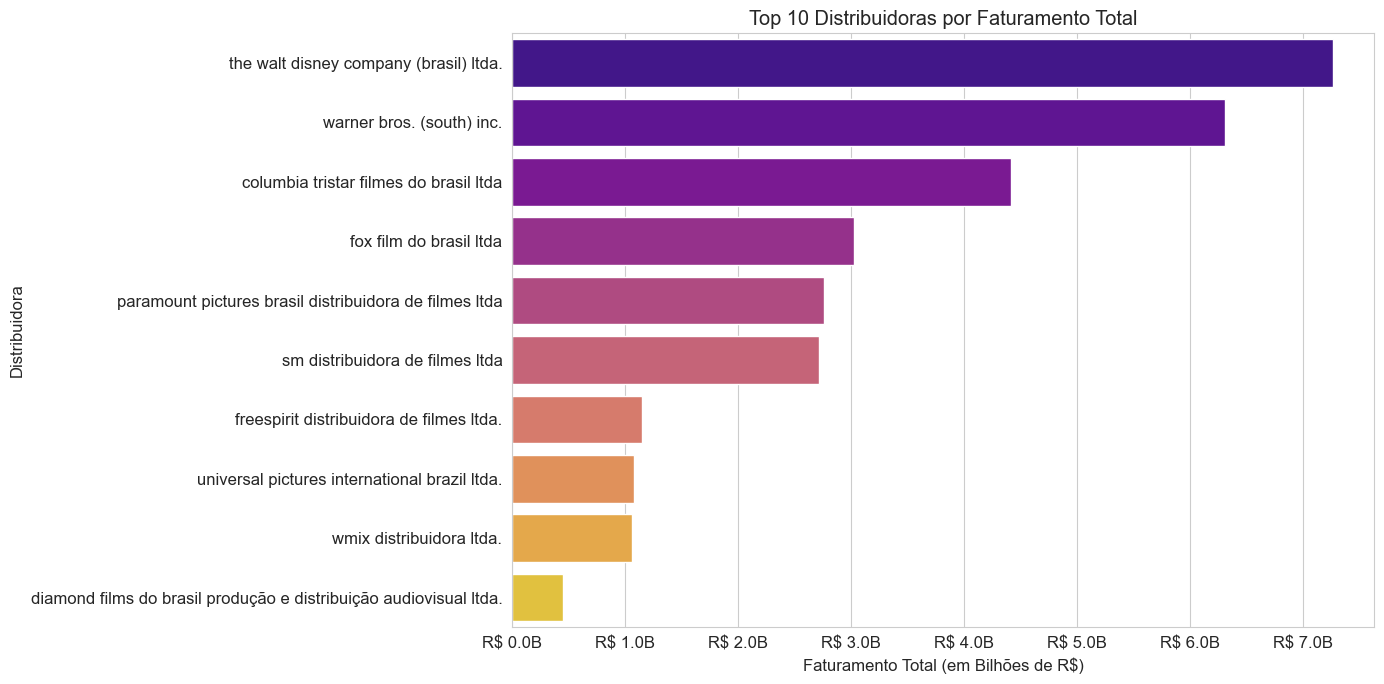

In [10]:
if df is not None:
    top_10_renda = df.groupby('distribuidora')['renda_total'].sum().sort_values(ascending=False).head(10)
    
    print("\nTop 10 Distribuidoras por Faturamento Total:")
    display(top_10_renda.apply(lambda x: f"R$ {x:,.2f}"))
    
    # Gráfico de barras (código atualizado para remover o aviso)
    ax = sns.barplot(x=top_10_renda.values, y=top_10_renda.index, hue=top_10_renda.index, palette='plasma', legend=False)
    ax.set_title('Top 10 Distribuidoras por Faturamento Total')
    ax.set_xlabel('Faturamento Total (em Bilhões de R$)')
    ax.set_ylabel('Distribuidora')
    
    # Formatação do eixo X para melhor leitura
    formatter = FuncFormatter(lambda x, pos: f'R$ {x/1e9:.1f}B')
    ax.xaxis.set_major_formatter(formatter)
    
    plt.tight_layout()
    plt.show()

Top 10 Filmes de Maior Bilheteria


Top 10 Filmes com Maior Bilheteria:


,titulo_original,renda_total,distribuidora,ano_lancamento
544,inside out 2,4.444441e+08,the walt disney company (brasil) ltda.,2024
2422,avengers: endgame,3.386250e+08,the walt disney company (brasil) ltda.,2019
1619,spider-man: no way home,3.174329e+08,columbia tristar filmes do brasil ltda,2021
2332,the lion king,2.659040e+08,the walt disney company (brasil) ltda.,2019
1224,avatar: the way of water,2.413956e+08,the walt disney company (brasil) ltda.,2022
2909,avengers: infinity war,2.377818e+08,the walt disney company (brasil) ltda.,2018
80,lilo & stitch,2.128650e+08,the walt disney company (brasil) ltda.,2025
993,barbie,2.097708e+08,warner bros. (south) inc.,2023
321,moana 2,1.777961e+08,the walt disney company (brasil) ltda.,2024
1502,doctor strange in the multiverse of madness,1.694304e+08,the walt disney company (brasil) ltda.,2022


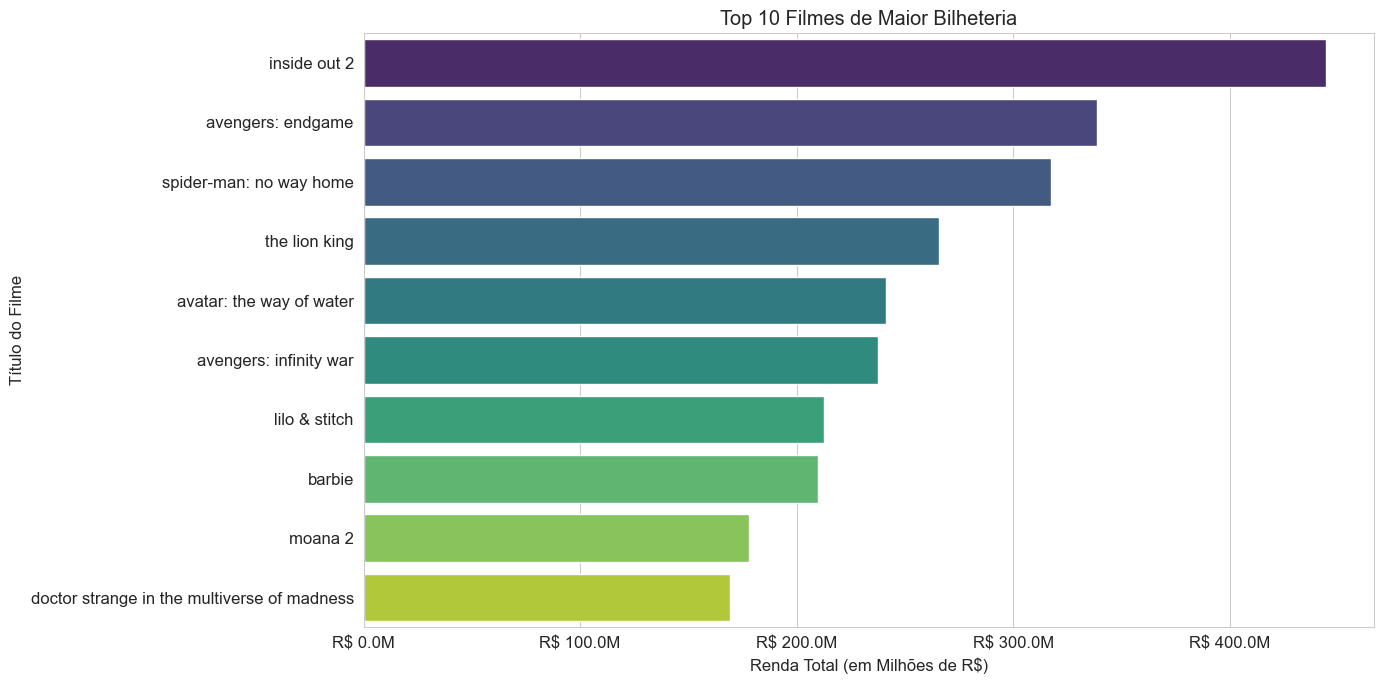

In [ ]:
if df is not None:
    top_10_filmes_renda = df.sort_values(by='renda_total', ascending=False).head(10)
    
    print("\nTop 10 Filmes com Maior Bilheteria:")
    # Mostrando colunas relevantes
    display(top_10_filmes_renda[['titulo_original', 'renda_total', 'distribuidora', 'ano_lancamento']])

    # Gráfico de barras
    ax = sns.barplot(x='renda_total', y='titulo_original', data=top_10_filmes_renda, hue='titulo_original', palette='viridis', legend=False)
    ax.set_title('Top 10 Filmes de Maior Bilheteria')
    ax.set_xlabel('Renda Total (em Milhões de R$)')
    ax.set_ylabel('Título do Filme')

    # Formatação do eixo X para melhor leitura
    formatter = FuncFormatter(lambda x, pos: f'R$ {x/1e6:.1f}M')
    ax.xaxis.set_major_formatter(formatter)

    plt.tight_layout()
    plt.show()

Faturamento por País de Origem da Obra


Top 10 Países por Faturamento Total Gerado:


pais_obra
estados unidos    R$ 25,356,912,141.57
brasil             R$ 3,492,272,027.90
canadá               R$ 822,490,524.74
frança               R$ 426,052,211.32
china                R$ 367,198,298.80
alemanha             R$ 195,841,573.13
espanha              R$ 173,769,461.71
reino unido          R$ 133,746,327.22
austrália            R$ 125,773,647.18
japão                 R$ 98,127,800.65
Name: renda_total, dtype: object

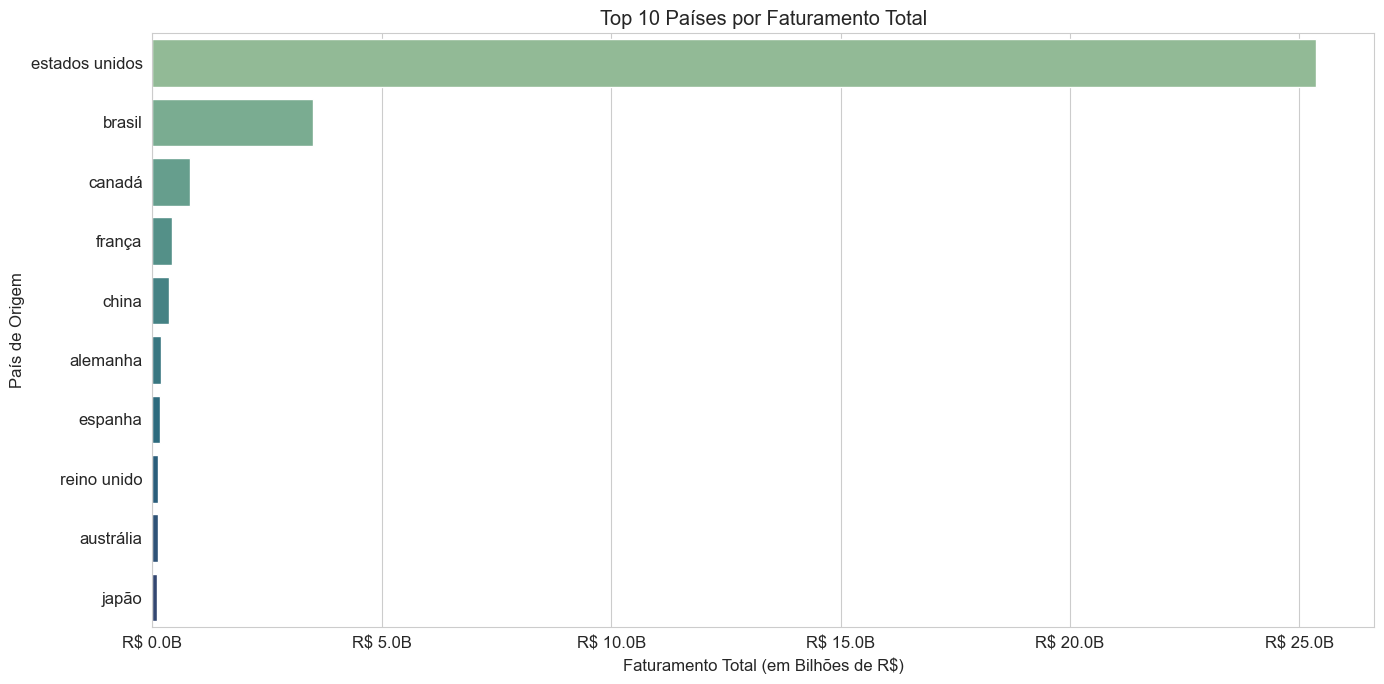

In [ ]:
if df is not None:
    top_10_paises = df.groupby('pais_obra')['renda_total'].sum().sort_values(ascending=False).head(10)
    
    print("\nTop 10 Países por Faturamento Total Gerado:")
    display(top_10_paises.apply(lambda x: f"R$ {x:,.2f}"))

    # Gráfico de barras
    ax = sns.barplot(x=top_10_paises.values, y=top_10_paises.index, hue=top_10_paises.index, palette='crest', legend=False)
    ax.set_title('Top 10 Países por Faturamento Total')
    ax.set_xlabel('Faturamento Total (em Bilhões de R$)')
    ax.set_ylabel('País de Origem')
    
    # Formatação do eixo X
    formatter = FuncFormatter(lambda x, pos: f'R$ {x/1e9:.1f}B')
    ax.xaxis.set_major_formatter(formatter)
    
    plt.tight_layout()
    plt.show()

Desempenho por Gênero/Tipo de Obra


Faturamento Total por Tipo de Obra:


tipo_obra
ficção                                R$ 25,641,950,424.05
animação                               R$ 5,754,063,388.69
variedades                               R$ 107,303,213.57
documentário                              R$ 85,027,154.96
vídeomusical                              R$ 41,860,475.78
religiosa                                 R$ 24,497,202.20
não classificada                             R$ 122,212.80
manifestações e eventos esportivos            R$ 35,217.00
jornalística                                  R$ 31,031.03
Name: renda_total, dtype: object

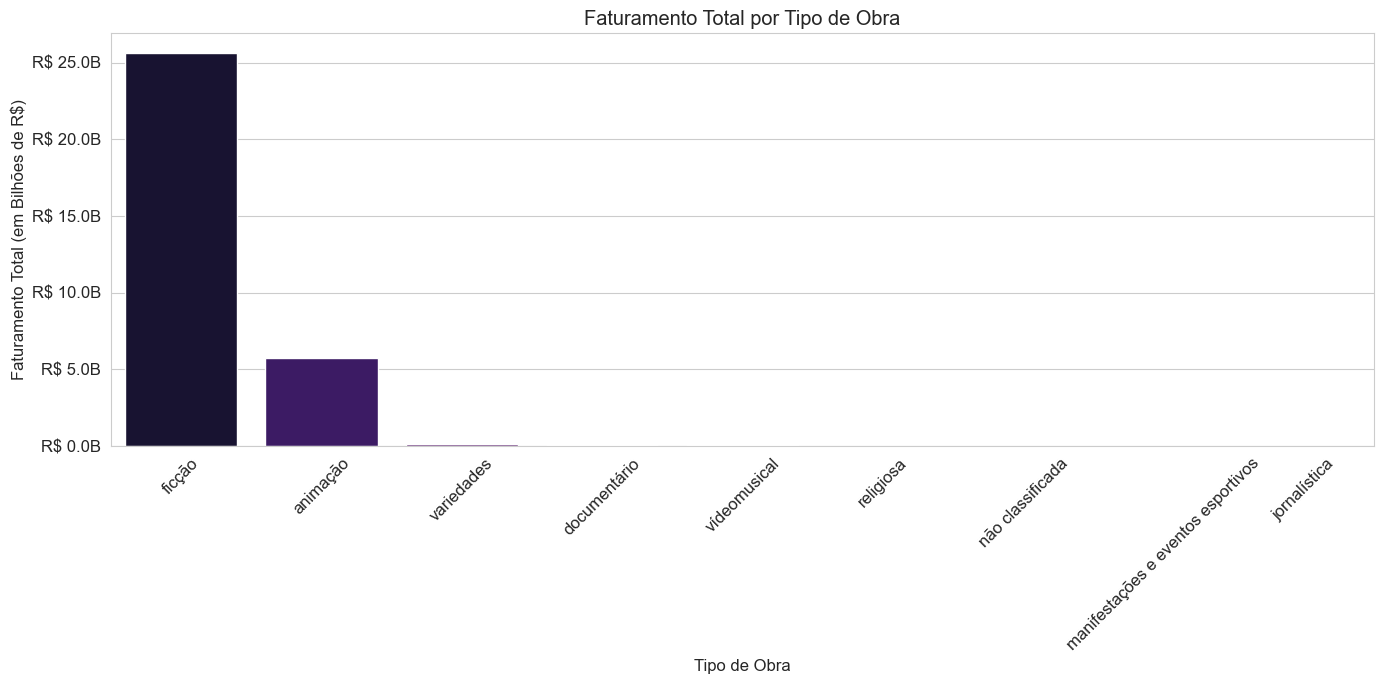

In [ ]:
if df is not None:
    renda_por_tipo = df.groupby('tipo_obra')['renda_total'].sum().sort_values(ascending=False)
    
    print("\nFaturamento Total por Tipo de Obra:")
    display(renda_por_tipo.apply(lambda x: f"R$ {x:,.2f}"))

    # Gráfico de barras
    ax = sns.barplot(x=renda_por_tipo.index, y=renda_por_tipo.values, hue=renda_por_tipo.index, palette='magma', legend=False)
    ax.set_title('Faturamento Total por Tipo de Obra')
    ax.set_xlabel('Tipo de Obra')
    ax.set_ylabel('Faturamento Total (em Bilhões de R$)')
    
    # Formatação do eixo Y
    formatter = FuncFormatter(lambda y, pos: f'R$ {y/1e9:.1f}B')
    ax.yaxis.set_major_formatter(formatter)
    
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

Relação entre Público e Renda

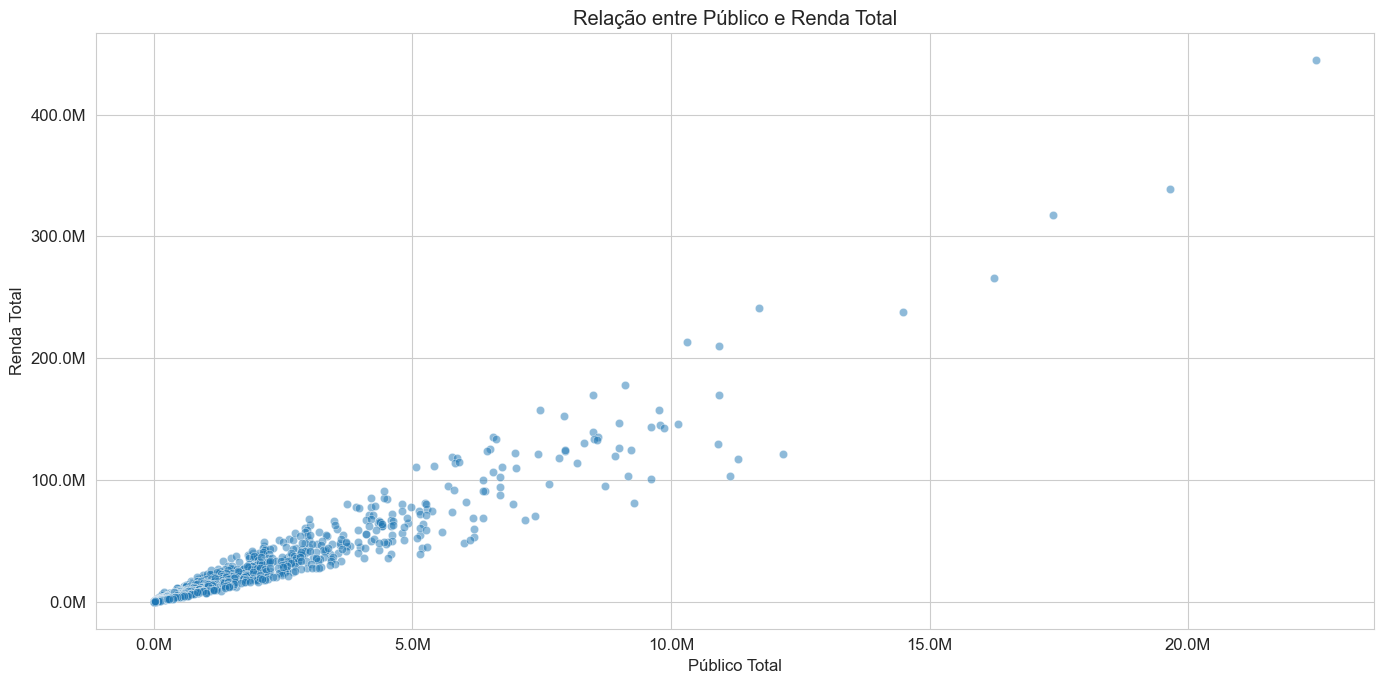

In [ ]:
if df is not None:
    # Para uma melhor visualização, podemos filtrar filmes com renda e público muito baixos
    df_filtrado = df[(df['publico_total'] > 1000) & (df['renda_total'] > 10000)]

    ax = sns.scatterplot(data=df_filtrado, x='publico_total', y='renda_total', alpha=0.5)
    ax.set_title('Relação entre Público e Renda Total')
    ax.set_xlabel('Público Total')
    ax.set_ylabel('Renda Total')
    
    # Formatação dos eixos
    formatter_milhoes = FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')
    ax.xaxis.set_major_formatter(formatter_milhoes)
    ax.yaxis.set_major_formatter(formatter_milhoes)
    
    plt.tight_layout()
    plt.show()

Top 10 Filmes por Ticket Médio

C:\Users\alvea\AppData\Local\Temp\ipykernel_33060\295226718.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels)


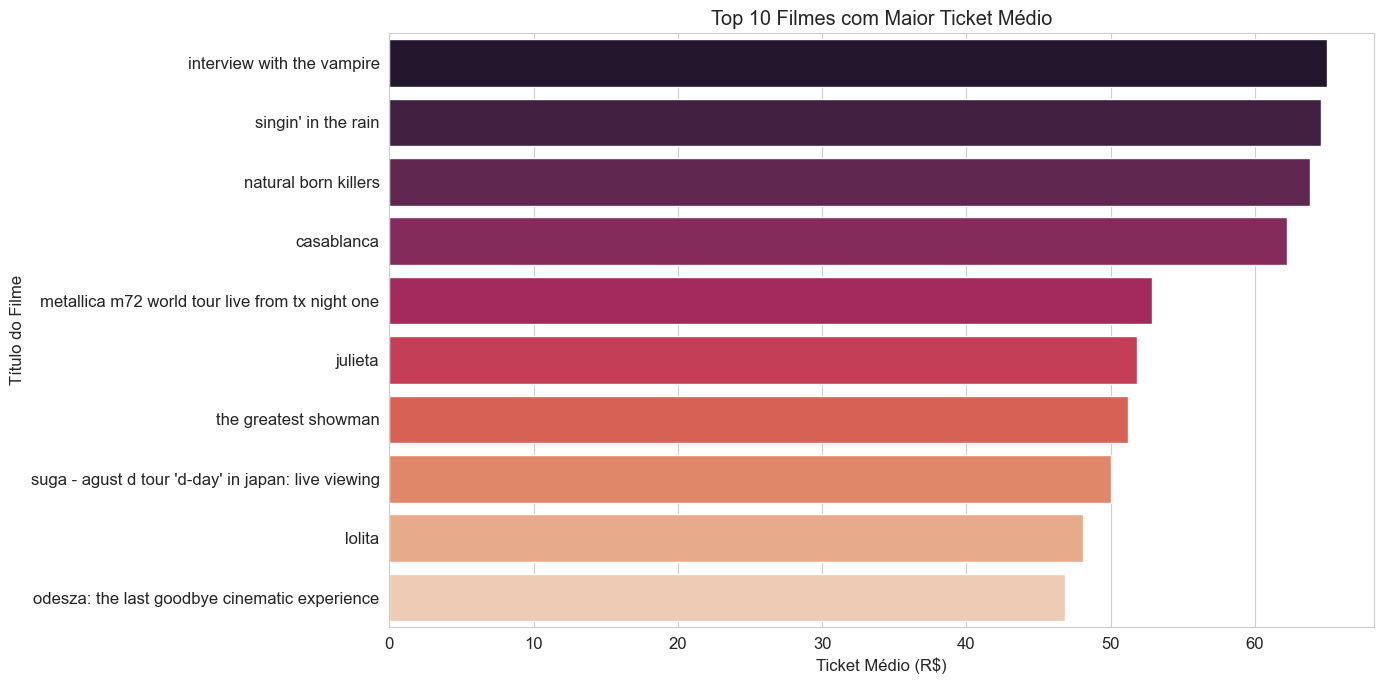

In [ ]:
if df is not None:
    # Calculando o ticket médio
    df['ticket_medio'] = df.apply(
        lambda row: row['renda_total'] / row['publico_total'] if row['publico_total'] > 0 else 0, 
        axis=1
    )
    
    # Aplicando método IQR para identificar outliers
    Q1_ticket = df['ticket_medio'].quantile(0.25)
    Q3_ticket = df['ticket_medio'].quantile(0.75)
    IQR_ticket = Q3_ticket - Q1_ticket
    
    limite_superior_ticket = Q3_ticket + 1.5 * IQR_ticket
    
    # Identificando outliers altos (acima do limite superior)
    outliers_alto = df[df['ticket_medio'] > limite_superior_ticket]
    
    # Selecionando os top 10 outliers para visualização
    top_10_ticket = outliers_alto.nlargest(10, 'ticket_medio')
    
    # Gráfico de barras dos top 10 tickets médios
    ax = sns.barplot(data=top_10_ticket, y='titulo_original', x='ticket_medio', 
                    hue='titulo_original', palette='rocket', legend=False)
    ax.set_title('Top 10 Filmes com Maior Ticket Médio')
    ax.set_xlabel('Ticket Médio (R$)')
    ax.set_ylabel('Título do Filme')
    
    # Truncar títulos longos para melhor visualização
    labels = [label.get_text()[:50] + '...' if len(label.get_text()) > 50 else label.get_text() 
             for label in ax.get_yticklabels()]
    ax.set_yticklabels(labels)
    
    plt.tight_layout()
    plt.show()

Top 10 Filmes com Menor Ticket Médio

C:\Users\alvea\AppData\Local\Temp\ipykernel_33060\2528611889.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels)


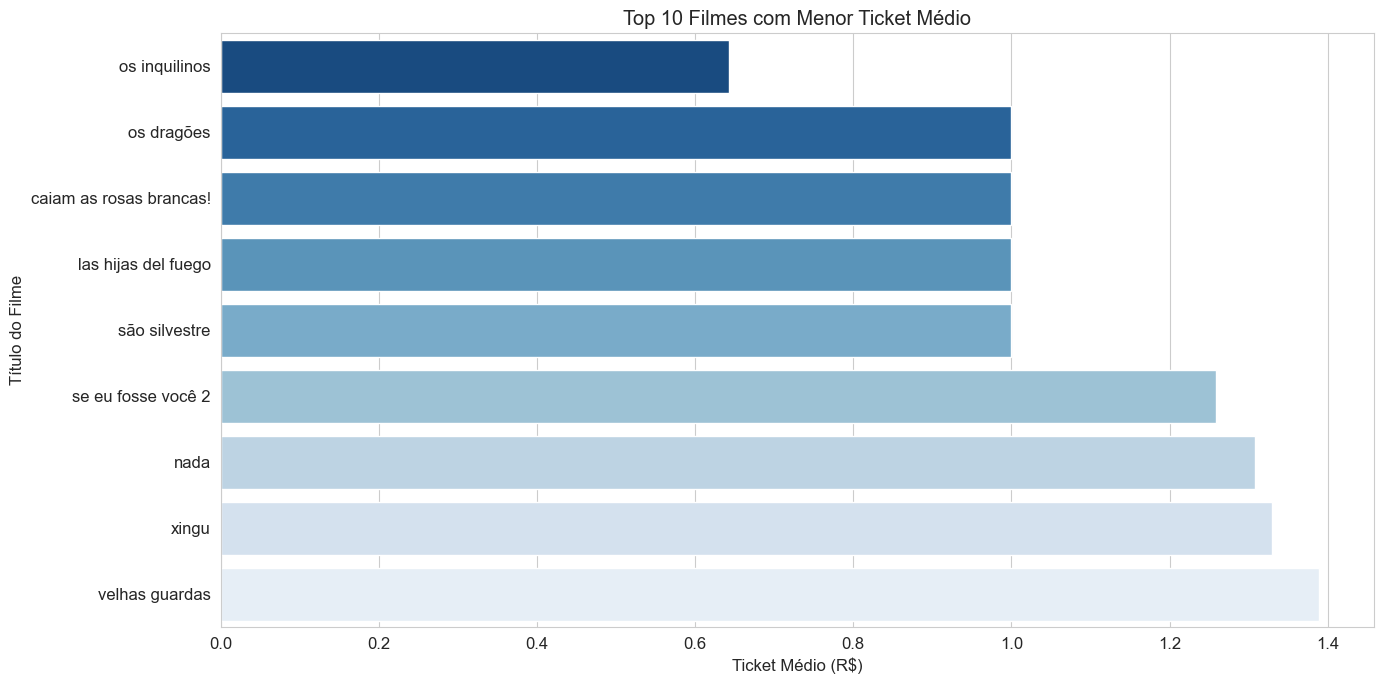

In [ ]:
if df is not None:
    # Usando os dados já calculados de ticket médio da célula anterior
    # Filtrar apenas filmes com público maior que 0 para evitar divisões por zero
    df_valido = df[df['publico_total'] > 0].copy()
    
    # Aplicando método IQR para identificar outliers baixos
    Q1_ticket = df_valido['ticket_medio'].quantile(0.25)
    IQR_ticket = df_valido['ticket_medio'].quantile(0.75) - Q1_ticket
    
    limite_inferior_ticket = Q1_ticket - 1.5 * IQR_ticket
    
    # Identificando outliers baixos (abaixo do limite inferior)
    outliers_baixo = df_valido[df_valido['ticket_medio'] < limite_inferior_ticket]
    
    # Se não há outliers baixos suficientes, pegar os 10 menores valores
    if len(outliers_baixo) < 10:
        top_10_menores = df_valido.nsmallest(10, 'ticket_medio')
    else:
        top_10_menores = outliers_baixo.nsmallest(10, 'ticket_medio')
    
    # Gráfico de barras dos top 10 menores tickets médios
    ax = sns.barplot(data=top_10_menores, y='titulo_original', x='ticket_medio', 
                    hue='titulo_original', palette='Blues_r', legend=False)
    ax.set_title('Top 10 Filmes com Menor Ticket Médio')
    ax.set_xlabel('Ticket Médio (R$)')
    ax.set_ylabel('Título do Filme')
    
    # Truncar títulos longos para melhor visualização
    labels = [label.get_text()[:50] + '...' if len(label.get_text()) > 50 else label.get_text() 
             for label in ax.get_yticklabels()]
    ax.set_yticklabels(labels)
    
    plt.tight_layout()
    plt.show()

Distribuição Completa de Tickets Médios